# Behavioral Segmentation and Completion Outcome Analysis

---

## Project Overview

### Objective

This project represents **Part 2** of the analytical workflow for the Interactive **Data Analysis in R Course** on **Stepik**.

The main objective of this phase is to segment users based on their resolved learning behavior and examine how these behavioral profiles are associated with course completion outcomes.

Part 1 identified the main product problem as an early **Activation Gap**: many users disengage before moving from passive content consumption into meaningful practical engagement. Building on this diagnostic finding, Part 2 uses unsupervised learning to summarize heterogeneous learner behavior into interpretable, business-actionable segments.

The goal of this phase is not to predict completion directly. Instead, the segmentation is used to understand which broad behavioral patterns exist among learners and how these patterns relate to completion outcomes.

The resulting segments provide an interpretive bridge between the descriptive product diagnosis in Part 1 and the supervised completion-risk modeling in Part 3.

---

### Project Context

This analytical workflow is organized into three connected stages.

**Part 1: Product Analysis, EDA, and Activation Gap Diagnosis**  
The first phase analyzed raw Stepik event and submission logs to identify where users disengage. It showed that the largest observed loss happens before the first meaningful practical action, especially before users start or submit assignments. This early drop-off was summarized as the **Activation Gap**.

Part 1 also prepared the downstream analytical foundation by applying P99-based filtering, excluding unresolved `in_progress` users, constructing user-level behavioral features, and exporting processed datasets for segmentation and prediction.

**Part 2: Behavioral Segmentation and Completion Outcome Analysis**  
This phase uses the resolved `model_base` sample to identify behaviorally distinct learner groups with K-means clustering. The resulting clusters are validated, profiled, interpreted, and then compared by completion outcome.

**Part 3: Early Completion Risk Modeling**  
The final phase uses early 10-day behavioral signals to estimate users' likelihood of eventual course completion and rank users by non-completion risk.

Cluster labels from Part 2 are treated as an exploratory business segmentation tool. They are not used as direct supervised-model inputs in Part 3, in order to keep the downstream prediction workflow based on observable early behavioral signals rather than post-hoc cluster assignments.

---

### Data Description

The analysis is based on processed user-level datasets derived from the `model_base` sample prepared in Part 1.

The `model_base` sample excludes:

- P99-defined extreme high-activity users,
- users still marked as unresolved `in_progress` at the dataset snapshot.

This makes the segmentation focus on resolved learner trajectories and reduces the influence of extreme or incomplete behavioral records.

**1. `cluster_features_model_base.csv`**

This dataset contains user-level behavioral features used for clustering.

**Granularity**

- **1 row = 1 user**
- **Total users:** 17,657

Main feature groups include:

**Engagement continuity**

- `active_days`
- `median_gap_days`

**Interaction intensity**

- `view_frequency`
- `submission_frequency`

**Learning pace and productivity**

- `steps_per_active_day`
- `score_per_active_day`

**Practical success behavior**

- `submission_correct_rate`

**2. `completion_target_model_base.csv`**

This dataset contains the final binary completion label for each user:

- `Completed`
- `Not_Completed`

The completion outcome is used only after clustering for segment interpretation. It is not included in the clustering feature space.

---

### Analytical Framing

This phase treats user behavior as heterogeneous rather than assuming that all non-completers disengage in the same way.

The segmentation is designed to answer the following business question:

**What types of learner behavior exist in the resolved user population, and how are these patterns associated with completion outcomes?**

The clustering does not use the final completion label. This is important because the objective is to discover behavioral profiles independently and then analyze whether these profiles differ in completion rates.

The resulting segments are therefore interpreted as behavioral archetypes, not as supervised prediction classes.

---

### Methodological Strategy

The workflow follows a structured unsupervised learning process.

1. **Data loading and integrity checks**
   - Load the processed clustering feature dataset and completion target dataset.
   - Verify user-level uniqueness.
   - Confirm that both datasets contain the same `user_id` set.
   - Check for missing values, invalid values, infinite values, duplicate users, and zero-variance features.

2. **Exploratory analysis of clustering features**
   - Inspect distributions of behavioral variables.
   - Identify right-skewness and residual local extreme values within the resolved sample.
   - Review the completion outcome distribution for later post-clustering interpretation.

3. **Feature preprocessing**
   - Apply `log1p` transformation to heavily right-skewed behavioral activity features.
   - Preserve `median_gap_days` in its original scale to retain behavioral meaning.
   - Apply Z-score normalization before K-means clustering.
   - Review the correlation structure to check for strong redundancy.

4. **K-means model selection**
   - Compare candidate cluster solutions.
   - Review the Elbow Method and Silhouette Score.
   - Compare **K = 3**, **K = 4**, and **K = 5** directly.
   - Evaluate whether higher-K solutions improve analytical value or mainly create small fragmented groups.

5. **Cluster validation**
   - Review cluster size distribution.
   - Use bootstrap-based stability diagnostics.
   - Compare K-means results with PAM as an additional robustness check.
   - Assess business interpretability of candidate solutions.

6. **Final cluster assignment and profiling**
   - Assign users to the selected cluster solution.
   - Reorder cluster labels by segment size for clearer reporting.
   - Profile clusters using original-scale behavioral metrics.
   - Interpret each segment as a business-actionable learner archetype.

7. **Completion outcome analysis**
   - Merge cluster assignments with completion labels.
   - Compare completion outcomes across segments.
   - Interpret associations between behavioral profiles and completion status.

8. **Strategic interpretation and downstream connection**
   - Summarize how behavioral segmentation supports retention strategy.
   - Connect the segment-level findings to the supervised completion-risk modeling in Part 3.

---

### Cluster Selection

The number of clusters was selected using both statistical diagnostics and business interpretability.

The candidate solutions included **K = 3**, **K = 4**, and **K = 5**.

Although the **K = 4** and **K = 5** solutions showed slightly higher Silhouette Scores, the improvement was marginal. At the same time, both higher-K alternatives introduced a very small additional segment of approximately **1.1%** of users.

From a business perspective, such small segments were not treated as standalone operational groups because they would require separate interpretation and potentially separate intervention logic without sufficient evidence of additional business value.

Therefore, the final primary segmentation uses **K = 3**, because it provides larger, more interpretable, and more business-actionable learner groups.

---

### Resulting Segments

The final **K = 3** solution identifies three learner segments.

**Passive Users (~50.3%)**  
Users with minimal engagement, almost no practical activity, and no observable score progress in the median profile.

**Steady Learners (~26.9%)**  
Users with sustained participation, moderate practical activity, and relatively stable learning progress.

**Burst Learners (~22.9%)**  
Users with concentrated high-intensity activity, strong practical engagement, and higher per-day productivity.

These segments capture meaningful differences in participation continuity, interaction intensity, practical engagement, and learning productivity.

---

### Completion Outcome Interpretation

Completion status is analyzed only after clustering and is not used to construct the segments.

The segment-level outcome distribution shows that `Not_Completed` remains the dominant outcome across all three segments. However, completion is relatively more frequent among the more engaged groups, especially **Steady Learners** and **Burst Learners**.

**Passive Users** show almost no successful completion, which reinforces the **Activation Gap** identified in Part 1. Users who do not move into practical engagement and sustained activity are very unlikely to complete the course.

This indicates that sustained participation and practical engagement intensity are positively associated with completion, although completion remains rare overall in the analytical sample.

---

### Key Analytical Questions

This project addresses five main questions:

1. **Can resolved learners be grouped into interpretable behavioral segments?**

2. **Which behavioral dimensions best distinguish learner profiles: continuity, intensity, productivity, or practical success?**

3. **Does a larger number of clusters improve business interpretability, or does it over-fragment the user base?**

4. **How are the final learner segments associated with completion outcomes?**

5. **How can behavioral segmentation inform downstream completion-risk modeling and retention strategy?**

---

### Key Findings

The analysis identifies several core findings.

**User engagement is highly heterogeneous.**  
The resolved learner population is not behaviorally uniform. Users differ substantially in continuity, activity intensity, practical engagement, and productivity.

**Most users belong to a low-engagement segment.**  
The largest segment is **Passive Users**, representing about half of the analytical sample. This group shows minimal engagement and almost no practical progress in the median profile.

**The final K = 3 solution is stable and business-actionable.**  
The selected segmentation produces three substantial user groups, avoids over-fragmentation, and is supported by bootstrap stability diagnostics and PAM comparison.

**More engaged segments show relatively higher completion shares.**  
Completion remains rare overall, but **Steady Learners** and **Burst Learners** show visibly higher completion shares than **Passive Users**.

**The segmentation supports the Activation Gap interpretation.**  
Users who fail to move from passive exposure into practical engagement and sustained activity are very unlikely to complete the course.

**Cluster labels are useful for interpretation, not prediction inputs.**  
The segments summarize behavioral archetypes and support business reasoning, but they are not used directly as features in the supervised modeling workflow in Part 3.

---

### Expected Business Use

The segmentation provides an exploratory business framework for understanding learner behavior.

The three segments can support differentiated retention thinking:

**Passive Users** may require stronger onboarding, first-task prompts, simplified entry points, and activation support.

**Steady Learners** may benefit from progress feedback, consistency reinforcement, and completion-oriented nudges.

**Burst Learners** may benefit from momentum-based recommendations, achievement prompts, and advanced progression support.

The segmentation should be treated as an interpretive business tool, not as a causal explanation or as a direct supervised-model input.

The findings from this phase support Part 3 by showing that early engagement, practical activation, activity intensity, and productivity are strongly related to learner outcomes. Part 3 then moves from descriptive segmentation to supervised modeling by estimating `P(Completed)` from early 10-day behavioral signals and converting it into a non-completion risk-ranking score:

`Risk_Not_Completed = 1 - P(Completed)`

---

### Assumptions & Limitations

**Assumptions**

- The processed datasets correctly represent the resolved analytical sample `model_base`.
- The selected behavioral features capture meaningful dimensions of learner engagement, continuity, practical activity, and productivity.
- Log transformation and Z-score normalization improve comparability across behavioral features for distance-based clustering.
- K-means provides a useful approximation of learner behavioral segments, even though real user behavior may vary along a continuum rather than in perfectly separated groups.
- The final K = 3 solution is treated as the primary business segmentation because it provides substantial and interpretable user groups.

**Limitations**

- The analysis is restricted to `model_base`, which excludes both P99-defined extreme users and users still marked as `in_progress` at the dataset snapshot. Therefore, results should not be interpreted as a full-population view of all learners.
- Completion remains a rare outcome in the analytical sample, so segment-level completion comparisons should be interpreted descriptively rather than as causal or inferential evidence.
- K-means assumes relatively compact cluster structure and is sensitive to feature selection, scaling, and preprocessing choices.
- The 3-cluster solution prioritizes business interpretability and segment size over finer-grained separation. Rare small-segment patterns observed in the K = 4 and K = 5 candidate solutions are not treated as standalone operational segments.
- Some clustering features include performance-related signals such as `submission_correct_rate` and `score_per_active_day`. This is acceptable for behavioral profiling, but it means the segmentation should be interpreted as a mixed behavioral-performance profile rather than a purely engagement-only segmentation.
- The analysis is based on a historical snapshot and does not capture unobserved external factors that may influence learner outcomes.
- Cluster labels are not causal explanations and should not be interpreted as fixed learner types.

---

In [1]:
# Environment Setup
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman")

In [2]:
pacman::p_load(data.table, dplyr, tidyr, corrplot, ggplot2, cluster, fpc, mclust)

---

## Data Loading 

In [3]:
# Project root 
project_root <- ".."

In [4]:
# Project paths
data_dir <- file.path(project_root, "data")
processed_data_dir <- file.path(data_dir, "processed")

In [5]:
# Using data.table::fread for high-performance data loading
cluster_features_model_base <- fread(file.path(processed_data_dir, "cluster_features_model_base.csv"))
completion_target_model_base <- fread(file.path(processed_data_dir, "completion_target_model_base.csv"))

In [6]:
# Display memory usage for the processed clustering and target datasets
cat("cluster_features_model_base size:", format(object.size(cluster_features_model_base), units = "MB"), "\n")
cat("completion_target_model_base size:", format(object.size(completion_target_model_base), units = "MB"), "\n")

cluster_features_model_base size: 0.9 Mb 
completion_target_model_base size: 0.2 Mb 


In [7]:
# Quick consistency check: verify dataset dimensions and user-level granularity
# Both datasets should contain 17,657 rows (one row per unique user)
# Column counts differ by design:
# - cluster_features_model_base: 8 behavioral features
# - completion_target_model_base: 2 columns 
dim(cluster_features_model_base)
dim(completion_target_model_base)

[1] 17657     8

[1] 17657     2

In [8]:
# Verification: Every row must represent one unique user (Primary Key check) - cluster_features_model_base
stopifnot(nrow(cluster_features_model_base) == n_distinct(cluster_features_model_base$user_id))

In [9]:
# Verification: Every row must represent one unique user (Primary Key check) - completion_target_model_base
stopifnot(nrow(completion_target_model_base) == n_distinct(completion_target_model_base$user_id))

In [10]:
# Verification: both datasets must contain the same user_id set
stopifnot(setequal(
  cluster_features_model_base$user_id,
  completion_target_model_base$user_id
))

---

## Exploratory Analysis

### EDA: Cluster Features

In [11]:
# Set seed for reproducibility of any sampling or randomized algorithms
set.seed(42)
cluster_features_model_base %>% slice_sample(n = 10)

user_id,active_days,median_gap_days,submission_correct_rate,view_frequency,submission_frequency,steps_per_active_day,score_per_active_day
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
14088,1,0,0.0000000,1.0000000,0.00000000,0.000000,0.000000
1885,1,0,1.0000000,19.0000000,1.00000000,9.000000,1.000000
23549,54,2,0.4953271,0.5564356,0.21188119,2.481481,1.074074
13390,1,0,1.0000000,11.0000000,2.00000000,8.000000,1.000000
15581,6,21,0.4166667,0.1985294,0.08823529,3.833333,0.500000
20406,1,0,0.0000000,1.0000000,0.00000000,1.000000,0.000000
21817,1,0,1.0000000,2.0000000,1.00000000,1.000000,1.000000
25417,1,0,0.0000000,3.0000000,0.00000000,3.000000,0.000000
11658,8,1,0.5576923,4.4473684,1.36842105,8.750000,3.625000


In [12]:
# Inspect dataset structure and variable types
glimpse(cluster_features_model_base)

Rows: 17,657
Columns: 8
$ user_id                 <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 2…
$ active_days             <int> 1, 2, 7, 2, 1, 2, 1, 1, 21, 1, 1, 1, 32, 2, 1,…
$ median_gap_days         <dbl> 0, 56, 2, 390, 0, 10, 0, 0, 2, 0, 0, 0, 1, 1, …
$ submission_correct_rate <dbl> 0.0000000, 1.0000000, 0.5576923, 0.5000000, 0.…
$ view_frequency          <dbl> 1.00000000, 0.17543860, 1.61344538, 0.03069054…
$ submission_frequency    <dbl> 0.00000000, 0.03508772, 0.43697479, 0.01023018…
$ steps_per_active_day    <dbl> 0.000000, 4.500000, 12.428571, 5.500000, 1.000…
$ score_per_active_day    <dbl> 0.000000, 0.500000, 4.142857, 0.500000, 0.0000…


In [13]:
# Review summary statistics to validate ranges and overall consistency
summary(cluster_features_model_base[, !c("user_id"), with = FALSE])

  active_days      median_gap_days   submission_correct_rate view_frequency   
 Min.   :  1.000   Min.   :  0.000   Min.   :0.0000          Min.   :  0.000  
 1st Qu.:  1.000   1st Qu.:  0.000   1st Qu.:0.0000          1st Qu.:  1.000  
 Median :  1.000   Median :  0.000   Median :0.0000          Median :  1.652  
 Mean   :  5.254   Mean   :  8.168   Mean   :0.3104          Mean   :  5.515  
 3rd Qu.:  5.000   3rd Qu.:  2.000   3rd Qu.:0.6000          3rd Qu.:  6.000  
 Max.   :385.000   Max.   :991.000   Max.   :1.0000          Max.   :262.000  
 submission_frequency steps_per_active_day score_per_active_day
 Min.   :  0.000      Min.   :  0.000      Min.   : 0.000      
 1st Qu.:  0.000      1st Qu.:  1.000      1st Qu.: 0.000      
 Median :  0.000      Median :  3.000      Median : 0.000      
 Mean   :  1.337      Mean   :  5.505      Mean   : 1.275      
 3rd Qu.:  1.000      3rd Qu.:  8.000      3rd Qu.: 1.400      
 Max.   :125.000      Max.   :185.000      Max.   :75.000      

**Executive Summary**

The `summary(cluster_features_model_base)` output describes behavioral data for **17,657 users** and reveals key patterns relevant for clustering:

- **Right-skewed distributions:** Most features show mean values above the median. For example, `view_frequency` has a median of **1.65** and a mean of **5.51**, indicating that a relatively small group of highly active users drives aggregate behavior.
- **Low baseline engagement:** Median `active_days` equals **1**, suggesting that at least half of users disengage after a single active day.
- **Temporal behavior:** Median `median_gap_days` equals **0**, but the upper tail is very large (up to **991**), capturing both short engagement bursts and prolonged inactivity.
- **Heterogeneous performance:** `submission_correct_rate` varies widely, with a median of **0.00** and a mean of **0.31**, indicating substantial variation in learner performance.
- **Heavy tails:** Several activity features retain very large upper-end values (for example, `view_frequency` up to **262**, `submission_frequency` up to **125**, and `steps_per_active_day` up to **185**), confirming substantial residual skewness.

**Clustering implication:** Due to **skewness**, **scale heterogeneity**, and persistent upper-tail dispersion, preprocessing via **log transformation** and **feature scaling** is required to ensure a stable and interpretable K-means clustering solution.

In [14]:
# Comprehensive sanity check for the clustering feature table
sanity_check_results <- cluster_features_model_base %>%  
  summarise(
    # Models like K-means cannot handle NA / NaN / Inf values
    na_count_total = sum(is.na(.)),

    # Domain checks
    invalid_active_days = sum(active_days < 1, na.rm = TRUE),

    # Bounded metric validation
    out_of_range_submission_correct_rate = sum(
    !dplyr::between(submission_correct_rate, 0, 1),
    na.rm = TRUE
    ),

    # Ensure no duplicate users (primary key integrity)
    duplicate_users = sum(duplicated(user_id))
  )

# Additional checks computed outside summarise()
feature_matrix <- as.matrix(dplyr::select(cluster_features_model_base, -user_id))

sanity_check_results$nan_count_total <- sum(is.nan(feature_matrix))
sanity_check_results$inf_count_total <- sum(is.infinite(feature_matrix))
sanity_check_results$zero_variance_features <- sum(apply(feature_matrix, 2, var) == 0)

# Report generation
sanity_report <- sanity_check_results %>%
  tidyr::pivot_longer(
    everything(),
    names_to = "Validation_Rule",
    values_to = "Error_Count"
  ) %>%
  as.data.frame()

sanity_report

Validation_Rule,Error_Count
<chr>,<int>
na_count_total,0
invalid_active_days,0
out_of_range_submission_correct_rate,0
duplicate_users,0
nan_count_total,0
inf_count_total,0
zero_variance_features,0


---

### EDA: Completion Target (Used for Post-Clustering Interpretation)

In [15]:
# Ensure correct factor levels
completion_target_model_base[, completion_status := factor(completion_status, levels = c("Not_Completed", "Completed"))]

In [16]:
# Basic structure check
glimpse(completion_target_model_base)

Rows: 17,657
Columns: 2
$ user_id           <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 26, 28,…
$ completion_status <fct> Not_Completed, Not_Completed, Not_Completed, Not_Com…


In [17]:
# Aggregate target distribution
completion_summary <- completion_target_model_base[, .(Count = .N), by = completion_status]
completion_summary[, Percentage := (Count / sum(Count)) * 100]

# Display target distribution
print(completion_summary)

   completion_status Count Percentage
              <fctr> <int>      <num>
1:     Not_Completed 16490  93.390723
2:         Completed  1167   6.609277


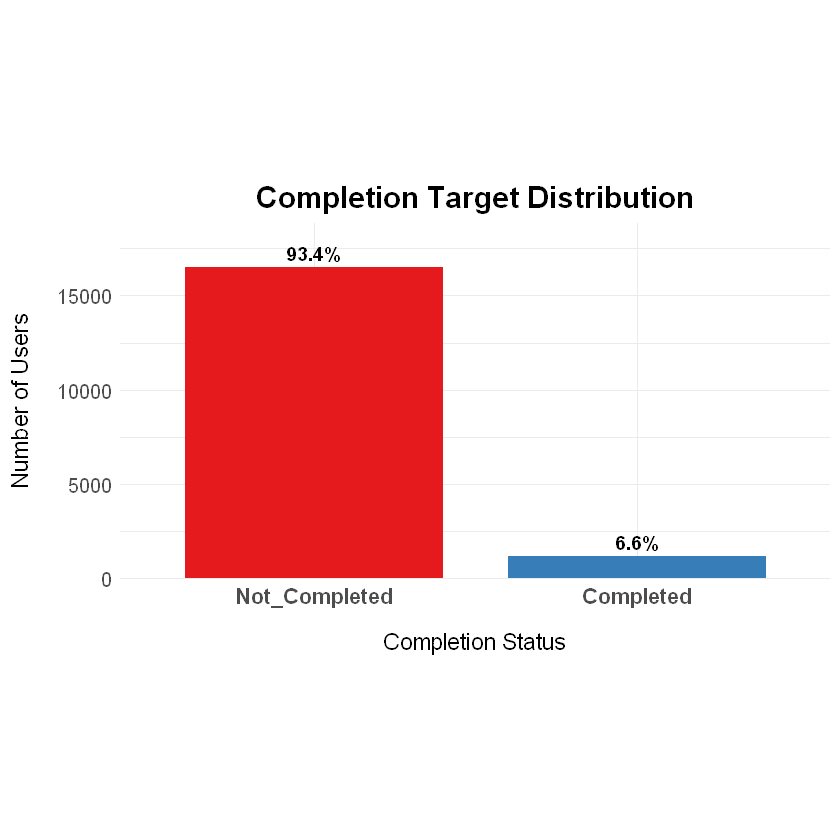

In [18]:
ggplot(completion_summary, aes(x = completion_status, y = Count, fill = completion_status)) +
  geom_bar(stat = "identity", width = 0.8) +
  geom_text(
    aes(label = paste0(round(Percentage, 1), "%")),
    vjust = -0.5,
    size = 4,
    fontface = "bold"
  ) +
  scale_y_continuous(
    limits = c(0, max(completion_summary$Count) * 1.12),
    expand = expansion(mult = c(0, 0.02))
  ) +
  scale_fill_manual(values = c("Not_Completed" = "#E41A1C", "Completed" = "#377EB8")) +
  labs(
    title = "Completion Target Distribution",
    x = "Completion Status",
    y = "Number of Users"
  ) +
  theme_minimal() +
  theme(
    aspect.ratio = 0.5,
    legend.position = "none",
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, margin = ggplot2::margin(t = 15)),
    axis.title.y = element_text(size = 14, margin = ggplot2::margin(r = 15)),
    axis.text.x = element_text(size = 13, face = "bold"),
    axis.text.y = element_text(size = 12)
  )

**Completion Target Analysis**

This completion target is used only for post-clustering interpretation and is not included in the clustering feature space.

>**Executive Summary:** The completion target is highly imbalanced: **93.4% Not_Completed** versus **6.6% Completed**. This indicates that course completion is a rare outcome in the analytical sample and that the dataset is strongly skewed toward non-completers.

**Key Implications:**

- The vast majority of users do not reach the completion threshold, reinforcing that successful completion is an exceptional rather than typical outcome.  
- The strong imbalance would make the positive class (Completed) difficult to learn and easy to overlook in any downstream supervised modeling task. 
- Standard accuracy is not an appropriate primary evaluation metric, since a naive model could achieve high accuracy by predicting only the majority class.  
- Model evaluation should therefore rely on minority-class-sensitive metrics such as **Precision, Recall, F1-score, PR-AUC**, and confusion-matrix-based interpretation.

---

## Behavioral Feature Engineering & Preprocessing

>**Technical Note: Note on the Analytical Sample**
>
>The clustering dataset is derived from model_base, which excludes both P99-defined extreme users and users still marked as in_progress at the dataset snapshot.

In [19]:
# Define base features for clustering 
features_clustering_base <- c(
    "active_days", 
    "median_gap_days", 
    "submission_correct_rate", 
    "view_frequency", 
    "submission_frequency", 
    "steps_per_active_day", 
    "score_per_active_day")

In [20]:
# Ensure all clustering features are numeric (required for distance-based algorithms)
sapply(cluster_features_model_base[, ..features_clustering_base], is.numeric)

active_days         median_gap_days submission_correct_rate 
                   TRUE                    TRUE                    TRUE 
         view_frequency    submission_frequency    steps_per_active_day 
                   TRUE                    TRUE                    TRUE 
   score_per_active_day 
                   TRUE

In [21]:
# Check variance for each feature: constant variables (var = 0) must be removed
apply(cluster_features_model_base[, ..features_clustering_base], 2, var)

active_days         median_gap_days submission_correct_rate 
             90.2975372            2111.0875300               0.1344839 
         view_frequency    submission_frequency    steps_per_active_day 
            112.9665093              16.5737212              55.3270946 
   score_per_active_day 
              7.2445569

>**Feature Variance Check**
>
>All selected features exhibit non-zero variance, confirming that no constant variables are present. 
>
>However, substantial differences in variance magnitude were observed across features 
(e.g., `median_gap_days` vs `submission_correct_rate`), indicating scale heterogeneity. 
>
>To prevent dominance of high-variance features in distance-based algorithms, 
all features are standardized prior to clustering.

---

### Log Transformation Diagnostics

>**Technical Note: Why Log Transformation Is Still Needed**
>
>Earlier diagnostics showed that P99-based filtering reduced extreme tails but did not eliminate the strong right-skewness of behavioral activity features. Therefore, log transformation is applied before standardization to reduce scale dominance in Euclidean distances and improve clustering stability.

In [22]:
# Baseline (no log transformation)
# Standardize original features without log transformation
scaled_raw_features <- scale(cluster_features_model_base[, ..features_clustering_base])

# Convert to data.frame for diagnostics
z_scores_raw <- as.data.frame(scaled_raw_features)

In [23]:
# IMPORTANT:
# 'median_gap_days' is intentionally excluded from log transformation.
# It represents inactivity periods, and large values carry meaningful behavioral signal.
# Log transformation would compress these differences and reduce interpretability.
# Define heavily right-skewed features for log transformation
skewed_features <- c(
  "active_days",
  "view_frequency",
  "submission_frequency",
  "steps_per_active_day",
  "score_per_active_day"
)

In [24]:
# Preserve user_id separately for later cluster assignment
user_ids <- cluster_features_model_base$user_id

In [25]:
# Create a working copy of the dataset for preprocessing
clustering_scaled <- copy(cluster_features_model_base)

In [26]:
# Apply log1p transformation to reduce skewness and limit the influence of extreme values
# log1p(x) = log(1 + x) ensures stability when zeros are present
clustering_scaled[, (skewed_features) := lapply(.SD, log1p), .SDcols = skewed_features]

# Standardize features using Z-score normalization (required for K-means)
# This ensures all features contribute equally to distance calculations
clustering_scaled <- scale(clustering_scaled[, ..features_clustering_base])

# Convert to data.frame for diagnostics
z_scores_log <- as.data.frame(clustering_scaled)

In [27]:
# Count observations beyond ±3 standard deviations for each feature
# This helps assess the impact of log transformation on extreme values

cat("\nExtreme values count (Z-score > ±3) — WITHOUT log transformation:\n")
print(apply(z_scores_raw, 2, function(x) sum(abs(x) > 3)))

cat("\nExtreme values count (Z-score > ±3) — WITH log1p transformation:\n")
print(apply(z_scores_log, 2, function(x) sum(abs(x) > 3)))


Extreme values count (Z-score > ±3) — WITHOUT log transformation:
            active_days         median_gap_days submission_correct_rate 
                    335                     251                       0 
         view_frequency    submission_frequency    steps_per_active_day 
                    303                     289                     253 
   score_per_active_day 
                    269 

Extreme values count (Z-score > ±3) — WITH log1p transformation:
            active_days         median_gap_days submission_correct_rate 
                    126                     251                       0 
         view_frequency    submission_frequency    steps_per_active_day 
                    106                     340                      25 
   score_per_active_day 
                    141 


**Impact of Log Transformation**

Log transformation was applied to **reduce right skewness** and **limit the influence** of extreme values in activity-based features.

 - **Observed Effects:**
   - For most features (e.g., `active_days`, `view_frequency`, `steps_per_active_day`),  
     log-transformation reduces the number of extreme values (**|Z| > 3**), improving distribution stability.
   - For `submission_frequency`, the number of Z-score heavy tails increases after transformation.  
     This is due to variance compression and does not indicate data quality issues.

- **Design Choice:** The feature `median_gap_days` is intentionally not transformed, as it **represents inactivity periods**.  
    Preserving its scale maintains important behavioral differences between users.

- **Outlier Handling:** Highly atypical users were excluded earlier during construction of `model_base`. Within the remaining sample, residual upper-tail variation was retained and handled through log transformation and standardization rather than additional removal.

**Conclusion**

Overall, log transformation improves feature balance and reduces scale dominance, making the resulting feature space more suitable for distance-based clustering.

---

### Correlation Matrix

In [28]:
# Calculate Pearson correlation for the final feature space
corr_matrix_final <- cor(clustering_scaled, use = "pairwise.complete.obs")

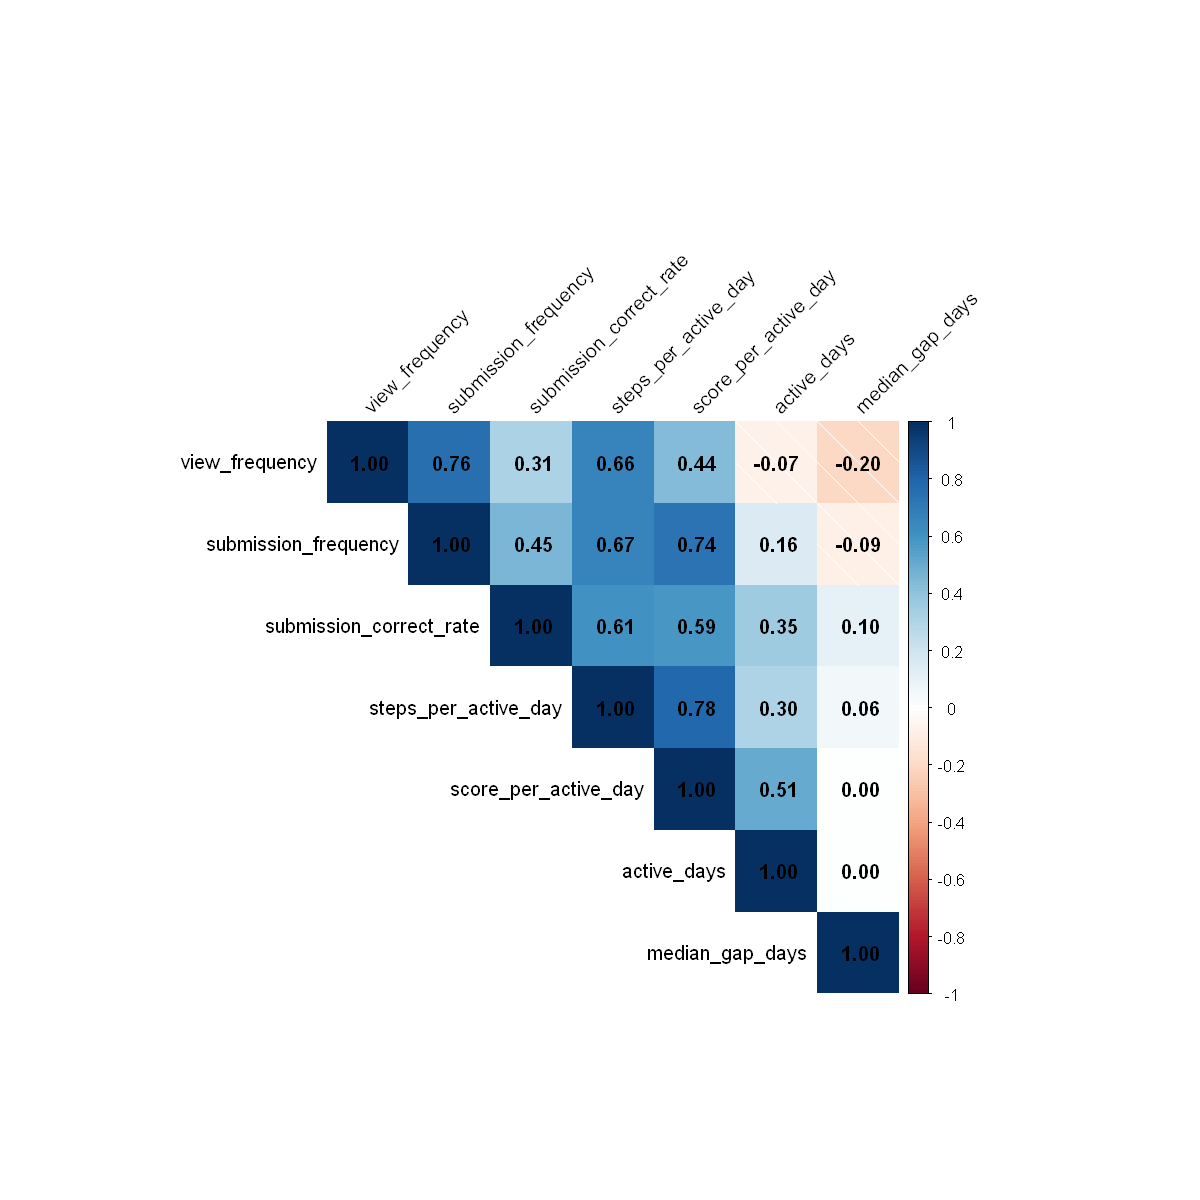

In [29]:
# Visualize correlations to inspect dependency structure across features
options(repr.plot.width = 10, repr.plot.height = 10)

corrplot(corr_matrix_final,
        method = "shade",
        type = "upper",
        order = "hclust",
        addCoef.col = "black",
        tl.col = "black",
        tl.srt = 45)

**Correlation Review**

The matrix shows expected positive relationships between engagement and productivity features. The strongest correlations are `steps_per_active_day` with `score_per_active_day` (**0.78**), `view_frequency` with `submission_frequency` (**0.76**), and `submission_frequency` with `score_per_active_day` (**0.74**).

`submission_correct_rate` is also moderately related to progress metrics, especially `steps_per_active_day` (**0.61**) and `score_per_active_day` (**0.59**). By contrast, `median_gap_days` has weak correlations with most features, suggesting that inactivity gaps capture a separate behavioral dimension.

 Overall, the features are related but not redundant, so they are retained for clustering.

---

**Behavioral Feature Engineering & Preprocessing Summary**

- **Feature scope:** The clustering feature set combines engagement intensity, participation rhythm, practical activity, and performance-related signals.
- **Preprocessing strategy:** Right-skewed activity features were log-transformed, `median_gap_days` was preserved in its original scale, and all selected features were standardized using Z-score normalization.
- **Result:** The final feature space (`clustering_scaled`) preserves multiple dimensions of learner behavior while improving stability and suitability for distance-based clustering.

---

## K-Means Clustering: Model Selection

### Elbow Method

In [30]:
# Set seed for reproducibility: K-means starts with random centroids, 
# so we fix the seed to get consistent results every time we run the code.
set.seed(42)

# Calculate WSS (Within-Cluster Sum of Squares) for different K values
wss <- sapply(1:10, function(k) {
  kmeans(clustering_scaled, centers = k, nstart = 20, iter.max = 50)$tot.withinss
})

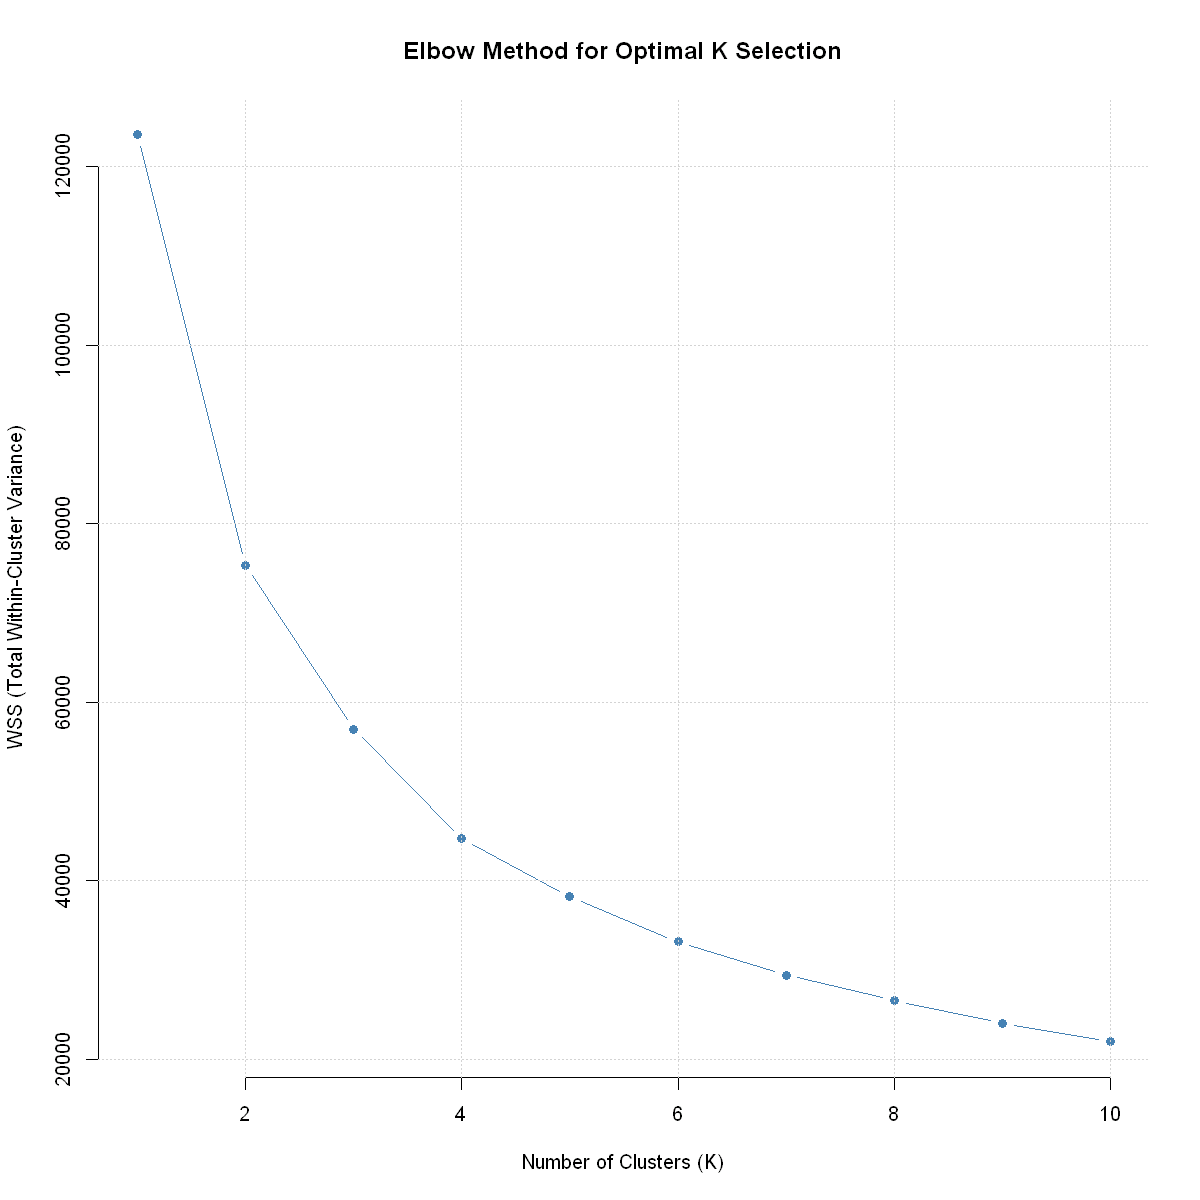

In [31]:
# Plotting the results to visually identify the 'elbow' point
plot(1:10, wss, type = "b", pch = 19, frame = FALSE, 
     xlab = "Number of Clusters (K)", 
     ylab = "WSS (Total Within-Cluster Variance)", 
     main = "Elbow Method for Optimal K Selection", 
     col = "steelblue")

grid()

**Optimal Cluster Selection: Elbow Method**

The Elbow Method was applied using WSS for $K = 1$ to $K = 10$ on the preprocessed feature space, where right-skewed activity variables were log-transformed and all selected features were standardized.

The curve shows a strong reduction in WSS up to approximately $K = 3$, with an additional visible improvement around $K = 4$. After $K = 4–5$, the marginal reduction in WSS becomes more gradual.

Therefore, the Elbow Method does not identify a single definitive optimal number of clusters. Instead, it suggests a plausible candidate range of $K = 3$ to $K = 5$.

For this reason, the final number of clusters is selected using additional criteria, including Silhouette Score, cluster size distribution, bootstrap stability, method comparison with PAM, and business interpretability.

---

### Silhouette Analysis

In [32]:
# Compute a common distance matrix for silhouette-based comparison
dmat <- dist(clustering_scaled)

In [33]:
# Compute the average Silhouette Score for a given number of clusters (K)
# using the preprocessed feature matrix and its corresponding distance matrix.
silhouette_score <- function(k, data_matrix, data_dist) {
  set.seed(42)
  model <- kmeans(data_matrix, centers = k, nstart = 50, iter.max = 100)
  ss <- cluster::silhouette(model$cluster, data_dist)
  mean(ss[, 3])
}

# Evaluate average Silhouette Scores for K = 2 to K = 10
sil_scores <- sapply(2:10, function(k) silhouette_score(k, clustering_scaled, dmat))
setNames(round(sil_scores, 3), 2:10)                     

2     3     4     5     6     7     8     9    10 
0.449 0.468 0.474 0.475 0.441 0.433 0.437 0.440 0.442

**Cluster Validation: Silhouette Analysis**

The Silhouette Score was calculated for $K = 2$ to $K = 10$ to assess cluster separation and cohesion.

The highest score is observed at $K = 5$ (**0.475**), while $K = 4$ is almost identical (**0.474**) and $K = 3$ is only slightly lower (**0.468**). The differences between these values are small, which means that the Silhouette analysis does not provide a decisive statistical reason to prefer one solution.

Therefore, **K = 3, K = 4, and K = 5** are retained as candidate solutions for direct comparison. The final decision is based not only on Silhouette Score, but also on cluster size distribution, stability, and business usability.

---

### Candidate Solution Comparison: K = 3, K = 4, and K = 5

In [34]:
# Fit candidate K-means solutions for comparison
set.seed(42)

kmeans_3 <- kmeans(
  x = clustering_scaled,
  centers = 3,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

kmeans_4 <- kmeans(
  x = clustering_scaled,
  centers = 4,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

kmeans_5 <- kmeans(
  x = clustering_scaled,
  centers = 5,
  nstart = 50,
  iter.max = 100,
  algorithm = "Hartigan-Wong"
)

In [35]:
# Silhouette comparison
sil_3 <- mean(cluster::silhouette(kmeans_3$cluster, dmat)[, 3])
sil_4 <- mean(cluster::silhouette(kmeans_4$cluster, dmat)[, 3])
sil_5 <- mean(cluster::silhouette(kmeans_5$cluster, dmat)[, 3])

In [36]:
# Cluster size comparison
k3_sizes <- data.table(
  K = 3,
  cluster = seq_along(kmeans_3$size),
  N = kmeans_3$size
)

k4_sizes <- data.table(
  K = 4,
  cluster = seq_along(kmeans_4$size),
  N = kmeans_4$size
)

k5_sizes <- data.table(
  K = 5,
  cluster = seq_along(kmeans_5$size),
  N = kmeans_5$size
)

cluster_size_k_compare <- rbind(k3_sizes, k4_sizes, k5_sizes)
cluster_size_k_compare[, Share := round(N / sum(N) * 100, 1), by = K]

In [37]:
# Summary table
k_comparison_summary <- data.table(
  K = c(3, 4, 5),
  silhouette_score = round(c(sil_3, sil_4, sil_5), 3),
  smallest_cluster_n = c(min(kmeans_3$size), min(kmeans_4$size), min(kmeans_5$size)),
  smallest_cluster_share = round(c(
    min(kmeans_3$size) / sum(kmeans_3$size) * 100,
    min(kmeans_4$size) / sum(kmeans_4$size) * 100,
    min(kmeans_5$size) / sum(kmeans_5$size) * 100
  ), 1)
)

k_comparison_summary
cluster_size_k_compare

K,silhouette_score,smallest_cluster_n,smallest_cluster_share
<dbl>,<dbl>,<int>,<dbl>
3,0.468,4035,22.9
4,0.474,195,1.1
5,0.475,196,1.1


K,cluster,N,Share
<dbl>,<int>,<int>,<dbl>
3,1,4744,26.9
3,2,8878,50.3
3,3,4035,22.9
4,1,8858,50.2
4,2,3830,21.7
4,3,4774,27.0
4,4,195,1.1
5,1,8632,48.9
5,2,1944,11.0


**Candidate Solution Comparison: K = 3, K = 4, and K = 5**

The candidate solutions K = 3, K = 4, and K = 5 were compared using two criteria: average Silhouette Score and cluster size distribution.

The Silhouette Score increases slightly from K = 3 to K = 4 and K = 5. However, the improvement is very small: K = 3 achieves a score of **0.468**, while K = 4 and K = 5 achieve **0.474** and **0.475**, respectively.

At the same time, both higher-K solutions create a very small cluster of approximately **1.1%** of the analytical sample. In the K = 4 solution, the smallest cluster contains **195 users**. In the K = 5 solution, the smallest cluster contains **196 users**.

From a business perspective, this indicates potential over-fragmentation. The additional clusters improve statistical separation only marginally, but introduce small segments that would be difficult to justify as standalone operational groups.

By contrast, the K = 3 solution produces three substantial segments, with the smallest cluster still representing **22.9%** of users. This makes K = 3 more suitable for scalable business segmentation, communication, and intervention design.

---

**Preliminary Cluster Selection**

Based on the comparison of K = 3, K = 4, and K = 5, **K = 3 is selected as the primary clustering solution**.

Although K = 4 and K = 5 show slightly higher Silhouette Scores, the improvement is marginal and comes at the cost of creating very small segments of only **1.1%** of users. These small groups may be useful as exploratory audit signals, but they are not large enough to justify separate business treatment in the primary segmentation.

Therefore, K = 3 is preferred because it provides a more balanced, interpretable, and business-actionable segmentation. The selected K = 3 solution is then evaluated further in the validation section using bootstrap stability diagnostics and comparison with PAM.

## K-Means Clustering: Validation

In [38]:
# Use the final K = 3 K-means model for validation and downstream segmentation
final_kmeans_model <- kmeans_3

### Cluster Size Distribution

In [39]:
# Cluster sizes for the final K = 3 solution.
# These are algorithm-internal cluster labels before the size-based relabeling used for reporting.
final_cluster_sizes <- data.table(
  algorithm_cluster = seq_along(final_kmeans_model$size),
  N = final_kmeans_model$size
)

final_cluster_sizes[, Share := round(N / sum(N) * 100, 1)]

final_cluster_sizes

algorithm_cluster,N,Share
<int>,<int>,<dbl>
1,4744,26.9
2,8878,50.3
3,4035,22.9


**Cluster Size Distribution Check**

The final **K = 3** solution produces three substantial algorithm-level clusters: **26.9%**, **50.3%**, and **22.9%** of the analytical sample. The smallest cluster still contains **4,035 users**, which is large enough for meaningful profiling and business interpretation.

These labels are algorithm-internal and are later reordered by segment size for reporting. This does not change the clustering solution; it only makes the final segment numbering easier to read.

Overall, the cluster size distribution supports the use of **K = 3** as a balanced and business-actionable segmentation. Unlike the **K = 4** and **K = 5** candidate solutions, it does not create a very small standalone segment of around **1.1%**.

---

### Cluster Stability Assessment

In [40]:
# Assess bootstrap stability of the final K = 3 solution
set.seed(42)

cb <- fpc::clusterboot(
  clustering_scaled,
  B = 100,
  clustermethod = fpc::kmeansCBI,
  krange = 3,
  seed = 42,
  count = FALSE,
  multipleboot = FALSE
)

# Average Jaccard stability score per cluster
setNames(round(cb$bootmean, 3), paste0("Cluster_", 1:3))

Cluster_1 Cluster_2 Cluster_3 
    0.975     0.895     0.894

In [41]:
# Compare final K-means cluster labels with bootstrap cluster assignments
mapping_table <- table(
  kmeans_cluster = final_kmeans_model$cluster,
  cb_cluster = cb$partition
)

mapping_table

              cb_cluster
kmeans_cluster    1    2    3
             1    0    0 4744
             2 8878    0    0
             3    0 4035    0

**Cluster Stability Assessment**

The bootstrap results support the final **K = 3** solution. All three clusters show high average Jaccard stability scores (**0.975**, **0.895**, **0.894**), indicating that the segmentation is reproducible under resampling.

The mapping table confirms a clean one-to-one correspondence between K-means and bootstrap cluster assignments. Differences in cluster numbering are expected because cluster labels are algorithm-internal.

Overall, the final **K = 3** solution is stable enough for downstream profiling and interpretation.

---

### Clustering Method Comparison (K-means vs PAM)

>**Technical Note: K-means vs PAM**
>
> To assess whether the identified behavioral structure depends strongly on the choice of clustering algorithm, the K-means solution was compared with PAM (Partitioning Around Medoids), a more robust medoid-based alternative.

In [42]:
# Fit PAM with the same number of clusters as the final K-means solution
set.seed(42)

pam_model <- cluster::pam(clustering_scaled, k = 3)
pam_clusters <- pam_model$clustering

In [43]:
# Average silhouette scores
pam_sil <- cluster::silhouette(pam_clusters, dmat)
mean_pam_sil <- mean(pam_sil[, 3])

kmeans_sil <- cluster::silhouette(final_kmeans_model$cluster, dmat)
mean_kmeans_sil <- mean(kmeans_sil[, 3])

In [44]:
# Compare cluster size distributions across methods
kmeans_sizes <- as.data.table(table(final_kmeans_model$cluster))
setnames(kmeans_sizes, c("cluster", "N"))
kmeans_sizes[, method := "K-means"]

pam_sizes <- as.data.table(table(pam_clusters))
setnames(pam_sizes, c("cluster", "N"))
pam_sizes[, method := "PAM"]

size_comparison <- rbind(kmeans_sizes, pam_sizes)

In [45]:
# Measure agreement between K-means and PAM partitions
ari_kmeans_pam <- mclust::adjustedRandIndex(
  final_kmeans_model$cluster,
  pam_clusters
)

In [46]:
# Print key comparison metrics with readable labels
cat("Mean silhouette score (PAM):      ", round(mean_pam_sil, 3), "\n")
cat("Mean silhouette score (K-means):  ", round(mean_kmeans_sil, 3), "\n")
cat("Adjusted Rand Index (K-means vs PAM): ", round(ari_kmeans_pam, 3), "\n")

cat("\nCluster size comparison:\n")
print(size_comparison)

Mean silhouette score (PAM):       0.467 
Mean silhouette score (K-means):   0.468 
Adjusted Rand Index (K-means vs PAM):  0.948 

Cluster size comparison:
   cluster     N  method
    <char> <int>  <char>
1:       1  4744 K-means
2:       2  8878 K-means
3:       3  4035 K-means
4:       1  8793     PAM
5:       2  4572     PAM
6:       3  4292     PAM


**Method Comparison Results**

The final **K = 3** K-means solution was compared with PAM as a robustness check.

The mean Silhouette Scores are almost identical: **0.468** for K-means and **0.467** for PAM. This indicates that both methods achieve a very similar level of internal cluster separation.

The Adjusted Rand Index is very high (**0.948**), showing strong agreement between the K-means and PAM partitions. This suggests that the main behavioral segmentation structure is not strongly dependent on the clustering algorithm.

The cluster size comparison also shows broadly similar segment structures across both methods. K-means produces three substantial segments of approximately **8.9k**, **4.7k**, and **4.0k** users, while PAM produces comparable segment sizes of approximately **8.8k**, **4.6k**, and **4.3k** users. The exact cluster numbering differs because cluster labels are algorithm-internal and do not have inherent meaning.

Overall, the comparison supports the robustness of the final **K = 3** solution. K-means is retained as the primary method, while PAM confirms that the three-segment behavioral structure is broadly reproducible.


---

### Final Cluster Decision

Based on the candidate comparison and validation results, **K = 3** is retained as the final primary segmentation.

The K = 3 solution has only a slightly lower Silhouette Score than K = 4 and K = 5, but it avoids very small standalone clusters and produces three substantial user groups. Bootstrap stability results show high cluster reproducibility, and the PAM comparison confirms that the three-segment structure is broadly robust across clustering methods.

Therefore, K = 3 provides the best balance between statistical quality, stability, interpretability, and business usability.

---

## K-Means Clustering: Assignment, Profiling, and Interpretation

### Cluster Assignment

In [47]:
# Create a size-based mapping to make cluster numbering more interpretable in reporting
cluster_labels <- data.table(
  user_id = user_ids,
  cluster = final_kmeans_model$cluster
)

In [48]:
# Merge cluster labels with RAW (non-transformed) features
segmentation_data <- merge(
  cluster_features_model_base,
  cluster_labels,
  by = "user_id"
)

In [49]:
# Verify that merging cluster labels did not change the user-level granularity
stopifnot(nrow(segmentation_data) == nrow(cluster_features_model_base))
stopifnot(segmentation_data[, uniqueN(user_id)] == nrow(cluster_features_model_base))

In [50]:
# Create size-based cluster mapping (largest cluster = 1)
cluster_size_map <- segmentation_data[, .(Count = .N), by = cluster][order(-Count)]
cluster_size_map[, new_cluster := 1:.N]

In [51]:
# Recode clusters in the interpretation dataset
segmentation_data[cluster_size_map, on = "cluster", cluster := i.new_cluster]

In [52]:
# Convert to factor after recoding
segmentation_data[, cluster := as.factor(cluster)]

> **Technical Note on Cluster Labels**
>
> K-means cluster numbers are algorithm-internal labels and have no inherent order. For reporting, clusters were reordered by segment size, so Cluster 1 represents the largest segment. This relabeling improves readability and does not change the clustering solution.

---

### Behavioral Profiling

In [53]:
# Recalculate cluster sizes AFTER recoding
cluster_sizes <- segmentation_data[, .(Count = .N), by = cluster]

In [54]:
# Cluster profiles are summarized using median values rather than means, 
# since the behavioral metrics are strongly right-skewed and contain extreme values. 
# This provides a more robust representation of typical user behavior within each segment.
cluster_profile <- segmentation_data[
  , lapply(.SD, median),
  by = cluster,
  .SDcols = features_clustering_base
]

In [55]:
# Merge sizes and profiles
display_table <- merge(cluster_sizes, cluster_profile, by = "cluster")

In [56]:
# Rename columns for reporting
setnames(display_table,
  c("cluster","Count","active_days","median_gap_days",
    "submission_correct_rate","view_frequency",
    "submission_frequency","steps_per_active_day","score_per_active_day"),
  c("Cluster_ID","Count","Active_Days","Median_Gap",
    "Success_Rate","Activity_Freq","Practice_Freq",
    "Steps_Per_Active_Day","Score_Per_Active_Day")
)


In [57]:
# Add cluster share as a percentage of the full analytical sample
display_table[, Share := round(Count / sum(Count) * 100, 1)]

In [58]:
# Reorder columns so that Share appears directly after Count
setcolorder(display_table, c(
  "Cluster_ID", "Count", "Share",
  "Active_Days", "Median_Gap", "Success_Rate",
  "Activity_Freq", "Practice_Freq",
  "Steps_Per_Active_Day", "Score_Per_Active_Day"
))

# Sort clusters by cluster ID for cleaner reporting
setorder(display_table, Cluster_ID)

# Display the final profiling table
display_table

Cluster_ID,Count,Share,Active_Days,Median_Gap,Success_Rate,Activity_Freq,Practice_Freq,Steps_Per_Active_Day,Score_Per_Active_Day
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8878,50.3,1,0,0.0000000,1.000000,0.0000000,1.000000,0.0
2,4744,26.9,9,2,0.5811966,1.129815,0.2619048,5.285714,1.2
3,4035,22.9,2,1,0.6428571,11.538462,3.0000000,10.166667,2.0


**Cluster Profile Table**

The table below summarizes the median behavioral profile of each cluster, together with cluster size and sample share. Median values are used to provide a robust representation of typical behavior within each segment, since the underlying behavioral variables are strongly right-skewed.

The profiles show clear heterogeneity across the three clusters in terms of participation continuity, activity intensity, practical engagement, and per-day productivity. These differences provide the empirical basis for the subsequent naming and interpretation of the behavioral segments.

---

### Segment Naming & Interpretation

In [59]:
# Mapping behavioral labels to cluster IDs
cluster_name_map <- data.table(
  cluster = as.factor(c(1, 2, 3)),
  cluster_name = c(
    "Passive Users",
    "Steady Learners",
    "Burst Learners"
  )
)

# Merge labels
segmentation_data <- merge(
  segmentation_data,
  cluster_name_map[, .(cluster, cluster_name)],
  by = "cluster"
)

# Optional integrity check: every user should now have a segment name
stopifnot(segmentation_data[, sum(is.na(cluster_name))] == 0)

**Behavioral Segmentation Analysis (K = 3)**

| Cluster | Segment Name | Size (%) | Profile | Key Insight |
|---|---|---:|---|---|
| **1** | Passive Users | **50.3%** | Minimal engagement, no meaningful practical activity, and no observable score progress in the median profile | Represents the dominant early-disengagement segment, where most users drop out before meaningful activation |
| **2** | Steady Learners | **26.9%** | The highest median number of active days, moderate practical participation, and stable learning progress | Represents the most sustained and behaviorally consistent learner segment |
| **3** | Burst Learners | **22.9%** | The highest median interaction frequency, practical intensity, and per-day productivity | Captures concentrated high-intensity learning behavior |

**Interpretive Summary**

The 3-cluster solution highlights substantial heterogeneity in learner behavior while keeping the segmentation balanced and business-actionable. The largest segment consists of users with minimal engagement and almost no practical progression, suggesting that disengagement is concentrated at the earliest stage of the learning journey.

The remaining two segments represent more engaged learning patterns: one with more sustained participation over time, and one with concentrated high-intensity activity. Overall, the main differences across segments are associated with continuity of participation, activity intensity, practical engagement, and per-day productivity.

Compared with the higher-K alternatives, this solution avoids creating very small standalone segments and is therefore more suitable for scalable business interpretation and retention strategy design.

---

## Completion Status Across User Segments

In [60]:
# Preserve row count before merge
n_before_merge <- nrow(segmentation_data)

# Merge target into segmentation dataset
segmentation_data <- merge(
  segmentation_data,
  completion_target_model_base,
  by = "user_id",
  all.x = TRUE
)

In [61]:
# Integrity checks after merge
stopifnot(nrow(segmentation_data) == n_before_merge)
stopifnot(segmentation_data[, uniqueN(user_id)] == n_before_merge)
stopifnot(segmentation_data[, sum(is.na(completion_status))] == 0)

In [62]:
# Fix segment order according to cluster ID
segmentation_data[, cluster := factor(cluster, levels = c(1, 2, 3))]
segmentation_data[, cluster_name := factor(
  cluster_name,
  levels = c(
    "Passive Users",
    "Steady Learners",
    "Burst Learners"
  )
)]

In [63]:
# Calculate target distribution within each cluster
cluster_completion <- segmentation_data[
  , .N, by = .(cluster, cluster_name, completion_status)
][
  , pct := N / sum(N), by = .(cluster, cluster_name)
]

In [64]:
# Reshape completion shares into a wide table:
# one row per segment, separate columns for Completed and Not_Completed
cluster_completion_wide <- dcast(
  cluster_completion,
  cluster + cluster_name ~ completion_status,
  value.var = "pct",
  fill = 0
)

In [65]:
# Convert proportions to percentages
cluster_completion_wide[, `:=`(
  Completed = round(Completed * 100, 1),
  Not_Completed = round(Not_Completed * 100, 1)
)]

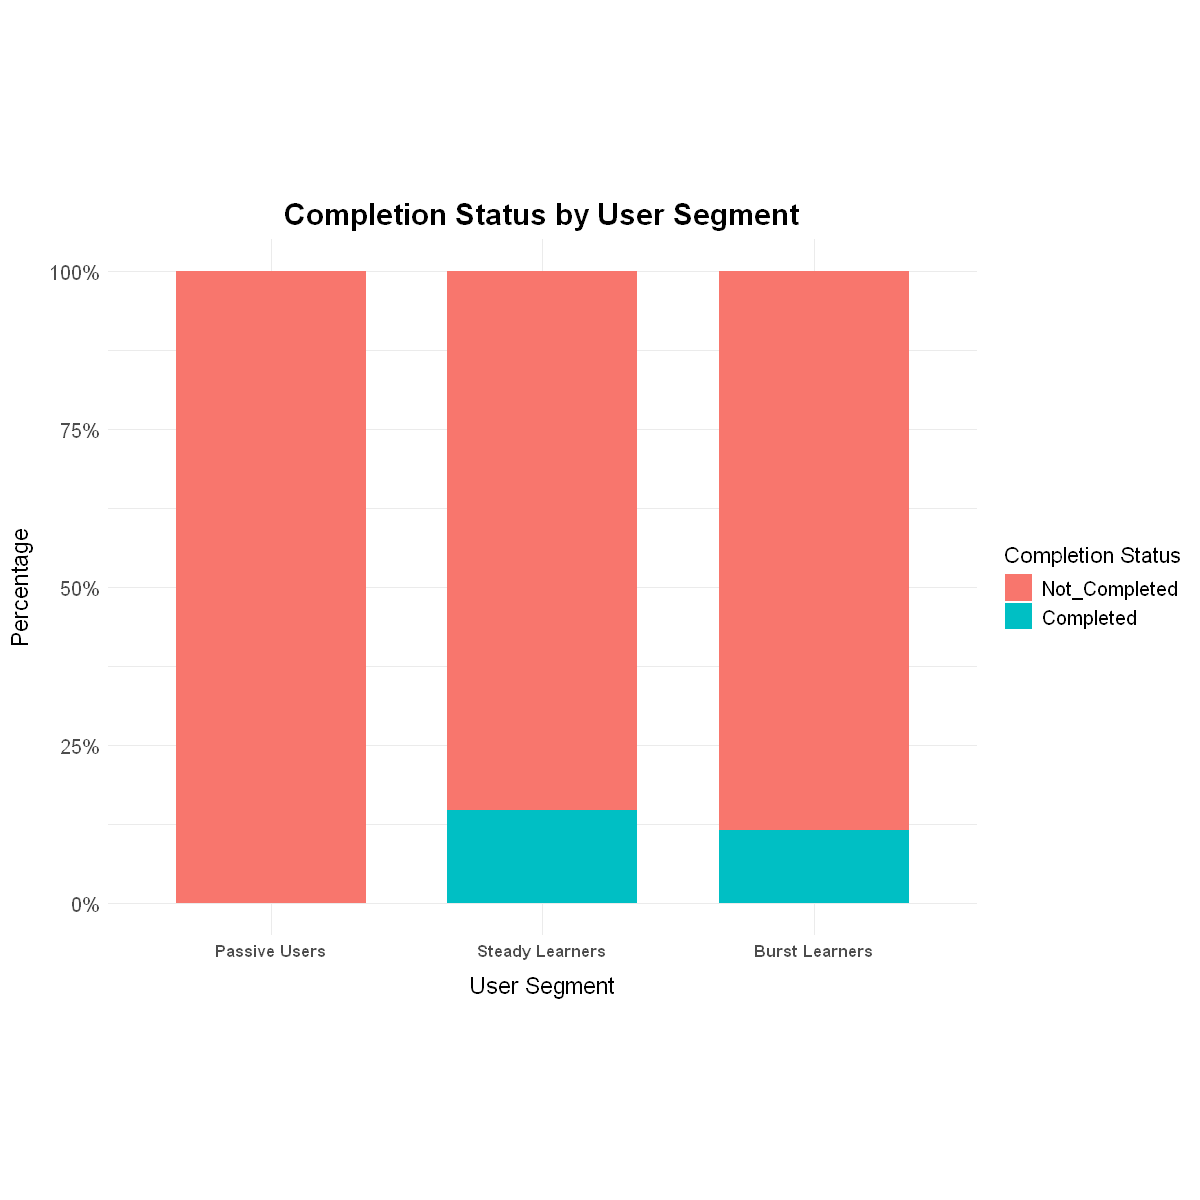

In [66]:
# Plot
ggplot(cluster_completion, aes(x = cluster_name, y = pct, fill = completion_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_y_continuous(labels = scales::percent) +
 labs(
  title = "Completion Status by User Segment",
  x = "User Segment",
  y = "Percentage",
  fill = "Completion Status"
  )+
  theme_minimal() +
  theme(
    aspect.ratio = 0.8,
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, margin = margin(t = 10)),
    axis.title.y = element_text(size = 14, margin = margin(r = 10)),
    axis.text.x = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 12),
    legend.title = element_text(size = 13),
    legend.text = element_text(size = 12)
  )

**Completion Status Across User Segments**

> **Executive Summary**
>
> The distribution of completion status differs across the three behavioral segments, but **Not_Completed** remains the dominant outcome in every group.
>
> Completion is almost absent among **Passive Users**, while both **Steady Learners** and **Burst Learners** show a visible minority of completed users. This supports the interpretation that stronger engagement, practical activity, and learning continuity are associated with a higher probability of course completion.

**Interpretation**

- **Passive Users**  
  This segment is almost entirely composed of **Not_Completed** users. The near-zero completion share is consistent with the segment profile: minimal engagement, no meaningful practical activity, and no observable score progress in the median profile.

- **Steady Learners**  
  This segment shows the highest completion share among the three groups. Although **Not_Completed** still remains the majority outcome, sustained participation over time appears to be positively associated with completion.

- **Burst Learners**  
  This segment also contains a visible share of completed users. Its completion pattern is consistent with concentrated high-intensity activity, stronger practical engagement, and higher per-day productivity. However, most users in this group still do not complete the course.

**Overall Conclusion**

The segment-level completion breakdown supports the behavioral validity of the 3-cluster solution. More engaged segments — especially **Steady Learners** and, to a lesser extent, **Burst Learners** — show higher completion shares than **Passive Users**.

At the same time, completion remains a minority outcome across all segments, reflecting the strong overall class imbalance in the analytical sample.

---

## Assumptions & Limitations

**Assumptions**

- The processed datasets correctly represent the resolved analytical sample (`model_base`) and are consistently linked by `user_id`.
- The selected behavioral features capture meaningful dimensions of learner engagement, continuity, practical activity, and performance.
- Log transformation and Z-score normalization improve comparability across behavioral features for distance-based clustering.
- The K-means solution provides a useful approximation of learner behavioral segments, even though real user behavior may vary along a continuum rather than in perfectly separated groups.
- The final 3-cluster solution is treated as the primary business segmentation because it provides substantial and interpretable user groups.

**Limitations**

- The analysis is restricted to `model_base`, which excludes both P99-defined extreme users and users still marked as `in_progress` at the dataset snapshot; therefore, results should not be interpreted as a full-population view of all learners.
- Completion remains a rare outcome in the analytical sample, so segment-level completion comparisons should be interpreted descriptively rather than as strong inferential evidence.
- K-means assumes relatively compact cluster structure and is sensitive to feature selection, scaling, and preprocessing choices.
- The 3-cluster solution prioritizes business interpretability and segment size over finer-grained separation. Rare small-segment patterns observed in the K = 4 and K = 5 candidate solutions are not treated as standalone operational segments.
- The analysis is based on a historical snapshot and does not capture unobserved external factors that may influence learner outcomes.

---

## Final Conclusion

This analysis shows that learner outcomes are strongly associated with **early disengagement, low practical activation, and weak behavioral continuity**, rather than with task difficulty alone.

The final behavioral segmentation identifies three core learner groups: **Passive Users**, who show minimal engagement and almost no practical progress; **Steady Learners**, who demonstrate the most sustained participation pattern; and **Burst Learners**, who show the highest interaction intensity and strongest per-day productivity.

The segment-level distribution of completion outcomes shows that **Not_Completed** remains the dominant outcome across all segments. At the same time, completion is relatively more frequent among the more engaged segments, especially **Steady Learners** and **Burst Learners**, while **Passive Users** show almost no successful completion.

These results indicate that clustering captures meaningful differences in engagement trajectories and helps explain why some users are more likely to progress toward completion than others. In particular, the analysis highlights that both **continuity of participation** and **practical engagement intensity** are important dimensions of learner success.

Overall, the final outcome of the analysis is twofold:

- a **behaviorally grounded 3-segment user structure** that explains distinct engagement trajectories, and  
- a **cluster-level interpretation of completion outcomes** that links behavioral profiles to course success.

This provides a stronger analytical foundation for both **retention strategy design** and **downstream completion modeling**, while keeping the segmentation practical and business-actionable.

**Connection to the Next Project Stage**

This segmentation analysis provides the exploratory behavioral context for the supervised modeling phase.

The final K = 3 solution shows that learner behavior can be summarized into three broad profiles: Passive Users, Steady Learners, and Burst Learners. These profiles confirm that engagement continuity, practical activation, and activity intensity are meaningfully associated with completion outcomes.

Part 3 builds on this insight by moving from segment-level interpretation to user-level prediction. Instead of using cluster labels as inputs, the supervised model uses early 10-day behavioral features to estimate `P(Completed)` and derive the inverted business risk score:

`Risk_Not_Completed = 1 - P(Completed)`

Thus, Part 2 explains behavioral heterogeneity, while Part 3 translates early behavioral signals into a practical retention prioritization workflow.

---